# Public investment and Yelp review sentiment
## Course Project Milestone 2 — Exploratory Data Analysis

### 1. Team information
**Team ID:** Team 4 · **Course:** CIS 509 · **Date:** September 5, 2026  
**Members:** John Wheeler (ASURITE: jwheele4), Ryan Wolff (ASURITE: rwwolff), Cameron Anthony (ASURITE: cantho19)

### 2. Project overview
City economic development staff and planners need ways to examine whether public investment is associated with changes in local business experiences. Our project joins federal funding records with Yelp review text and presents the results in a geographic interface.

The question is: **Do places receiving different types and amounts of federal assistance show different patterns in business-review sentiment?** This EDA tests whether our data can support that question. Yelp sentiment measures reviewers' experiences with businesses; it is not a direct measure of residents' well-being or a representative neighborhood survey. An association would not establish that funding caused a change.

We examine three prerequisites: whether the sources overlap in place and time, whether review coverage is adequate, and whether funding descriptions identify investments plausibly relevant to nearby businesses. These checks determine which analyses are worth pursuing next.

### 3. Data sources and selection
| Source | Contents used | Selection and collection |
|---|---|---|
| [Yelp Open Dataset](https://www.yelp.com/dataset) | Business metadata, review text, star ratings, review dates | Existing local archive; business ZIP matched to the project's five-region ZIP list. Full years 2012–2021 only. All business categories and open/closed businesses retained. |
| [USASpending](https://www.usaspending.gov/) / [API](https://api.usaspending.gov/docs/) | Prime assistance transactions, obligation amount, action date, place-of-performance ZIP, program code and descriptions | Existing annual `assistance_2012.zip` through `assistance_2021.zip` downloads. The project's fetcher requests award types 02–05 and place-of-performance ZIPs in its 1,202-ZIP Yelp universe. Here we further restrict to the five-region ZIP list. |
| [Census TIGERweb](https://tigerweb.geo.census.gov/arcgis/rest/services/TIGERweb/tigerWMS_ACS2023/MapServer/2) | ZCTA polygons and identifiers | Existing ACS2023 service extract; checked for identifier coverage, not treated as historical neighborhood boundaries. |

The five regions are Tucson, Philadelphia, Tampa Bay, Nashville, and New Orleans. They are **project-defined ZIP groups**, not official metropolitan statistical areas or representative samples of US cities. Their membership comes from `metro_zips.json`.

For comparable annual coverage, this milestone uses only the ten assistance files above. Contracts, loans (including PPP/EIDL), recipient-address extracts, and partial 2022 data are outside this EDA. Dollar amounts are nominal **transaction obligations**, including negative adjustments; they are not expenditures or physical construction completion dates. We do not combine recipient-location and place-of-performance records.

The existing `award_transactions.csv` contains only 2015. We therefore reconstruct the EDA funding table from the raw annual archives. Existing review-level VADER scores and the ZIP-quarter sentiment panel are audited below; a separate seeded text sample is read from the original Yelp archive.

#### Reproduction
Run all cells in order with Python 3.12 and `pandas`, `numpy`, `matplotlib`, `scikit-learn`, `vaderSentiment`, `nbformat`, `nbconvert`, and `ipykernel`. The project data remain local; they are not embedded in this notebook. The rendered HTML contains the tables and figures needed to read the analysis without those files.

By default the notebook finds `neighborhood-sentiment-map` beside the course's `Work` folder. Set the `EDA_PROJECT_ROOT` environment variable to use another location. The first run streams the Yelp archive and annual funding downloads; subsequent runs reuse a cache keyed to source file sizes and modification times. Delete `_eda_cache` to force re-extraction. The sampled text is used for diagnostics only and is not printed in the submitted outputs.

In [1]:
from pathlib import Path
import os, json, gzip, tarfile, zipfile, random, re, hashlib, platform
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import confusion_matrix
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

candidates = [Path(os.environ.get('EDA_PROJECT_ROOT', '__unset__'))]
for parent in [Path.cwd(), *Path.cwd().parents]:
    candidates += [parent / 'neighborhood-sentiment-map', parent / 'CIS-509-Analytics-Unstructured-Data/neighborhood-sentiment-map']
ROOT = next((p.resolve() for p in candidates if (p / 'data/interim/metro_zips.json').exists()), None)
assert ROOT is not None, 'Set EDA_PROJECT_ROOT to the existing neighborhood-sentiment-map data project.'
CACHE = Path.cwd() / '_eda_cache'; CACHE.mkdir(exist_ok=True)
FIGS = Path.cwd() / '_eda_figures'; FIGS.mkdir(exist_ok=True)
SEED, SAMPLE_PER_REGION = 509, 1000
metro_zips = json.loads((ROOT / 'data/interim/metro_zips.json').read_text())
zip_metro = {z:m for m,zs in metro_zips.items() for z in zs}
assert sum(map(len,metro_zips.values())) == len(zip_metro), 'ZIP belongs to multiple regions.'
plt.rcParams.update({'figure.dpi':120, 'font.size':10, 'axes.spines.top':False,
                     'axes.spines.right':False, 'axes.titleweight':'bold'})
COLORS = ['#235789','#16817A','#C17C24','#81559B','#C45555']
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=COLORS)
pd.options.display.float_format = '{:,.3f}'.format
pd.options.display.max_colwidth = 65

def showfig(name):
    plt.tight_layout(); plt.savefig(FIGS / (name+'.png'), bbox_inches='tight'); plt.show()

def signature(paths):
    records = [(str(p.relative_to(ROOT)), p.stat().st_size, p.stat().st_mtime_ns) for p in paths]
    return hashlib.sha256(json.dumps(records).encode()).hexdigest()

print('Python', platform.python_version(), '| pandas', pd.__version__, '| seed', SEED)
print('Study ZIPs:', len(zip_metro), '| full years: 2012–2021 | text sample target:', SAMPLE_PER_REGION, 'per region')

Python 3.12.1 | pandas 3.0.5 | seed 509
Study ZIPs: 277 | full years: 2012–2021 | text sample target: 1000 per region


### 4. Data description and summary statistics
We keep units of analysis separate: businesses, reviews, assistance transactions, and ZIP-quarter aggregates. A transaction is not a distinct award, and millions of reviews do not imply millions of independent neighborhood observations.

| Analytical fields | Type | Interpretation |
|---|---|---|
| Business/review/award/transaction IDs | String | Entity identifiers; award and transaction IDs have different units |
| ZIP, region, program code | String/category | Join/grouping fields; leading zeros and program-code punctuation preserved |
| Review date, action date, quarter | Date/time or period label | Review timing and award transaction timing; not project completion |
| Review text, program title, award description | Text | Inputs to sentiment, keywords, and future relevance classification |
| Stars | Ordinal numeric, 1–5 | Reviewer rating; a sentiment proxy |
| VADER compound | Numeric, −1 to +1 | Lexicon-based sentiment score |
| Obligation | Numeric, nominal dollars | Signed federal commitment/adjustment amount |
| Review count, negative percentage | Integer / numeric | Coverage and distribution summaries |
| Latitude/longitude, snapshot open status | Numeric / binary | Business location and current-at-snapshot status, not historical status |


In [2]:
business_path = ROOT / 'data/raw/yelp_academic_dataset_business.json'
business = pd.read_json(business_path, lines=True)
business['postal_code'] = business['postal_code'].astype('string').str.strip()
biz = business[business['postal_code'].isin(zip_metro)].copy()
biz['metro'] = biz['postal_code'].map(zip_metro)
assert not biz['business_id'].duplicated().any()
sent = pd.read_csv(ROOT / 'data/interim/sentiment_zip_quarter.csv', dtype={'zip5':str})
sent['metro'] = sent['zip5'].map(zip_metro)
sent['year'] = sent['quarter'].str[:4].astype(int)
assert sent['metro'].notna().all() and sent['year'].between(2012,2021).all()
assert not sent.duplicated(['zip5','quarter']).any()
assert sent['n_reviews'].gt(0).all() and sent['mean_compound'].between(-1,1).all()
display(pd.DataFrame({'table':['Full Yelp business file','Study businesses','Existing ZIP-quarter sentiment panel'],
                      'rows':[len(business),len(biz),len(sent)],
                      'source_columns':[len(business.columns),len(business.columns),len(sent.columns)-2]}))
display(biz.groupby('metro').agg(businesses=('business_id','size'), ZIPs=('postal_code','nunique'),
    open_at_snapshot=('is_open','mean')).join(sent.groupby('metro')['n_reviews'].sum().rename('reviews_2012_2021')))
print('Business metadata fields:', ', '.join(business.columns))
print('Sentiment panel fields: ZIP (string), quarter (string), review count (integer), mean compound/mean stars/negative percent (numeric).')
category_counts = biz['categories'].dropna().str.split(', ').explode().value_counts()
display(category_counts.head(10).rename('Businesses with category (overlapping)').to_frame())
restaurant_share = biz['categories'].fillna('').str.split(', ').map(lambda tags: 'Restaurants' in tags).mean()
display(Markdown(f'**{restaurant_share:.1%} of study businesses carry the Restaurants category.** Categories overlap, and review activity need not follow the business mix. Later comparisons should check category composition, rather than treating all business experiences as interchangeable.'))


,table,rows,source_columns
0,Full Yelp business file,150346,14
1,Study businesses,55465,14
2,Existing ZIP-quarter sentiment panel,9168,6


,businesses,ZIPs,open_at_snapshot,reviews_2012_2021
metro,,,,
Nashville,6869,33,0.776,420185
NewOrleans,6459,40,0.753,589439
Philadelphia,14574,59,0.723,825895
TampaBay,17947,98,0.805,846734
Tucson,9616,47,0.816,390928


Business metadata fields: business_id, name, address, city, state, postal_code, latitude, longitude, stars, review_count, is_open, attributes, categories, hours
Sentiment panel fields: ZIP (string), quarter (string), review count (integer), mean compound/mean stars/negative percent (numeric).


,Businesses with category (overlapping)
categories,
Restaurants,19177
Food,10442
Shopping,8780
Nightlife,5452
Home Services,5380
Beauty & Spas,5117
Bars,4891
Health & Medical,4330
Local Services,4079


**34.6% of study businesses carry the Restaurants category.** Categories overlap, and review activity need not follow the business mix. Later comparisons should check category composition, rather than treating all business experiences as interchangeable.

3,073,181 scored reviews reconcile with the ZIP-quarter panel; saved score ranges and weighted means pass checks.


,Missing values in full review-score file
zip5,0
metro,0
date,0
quarter,0
stars,0
compound,0
is_open,0


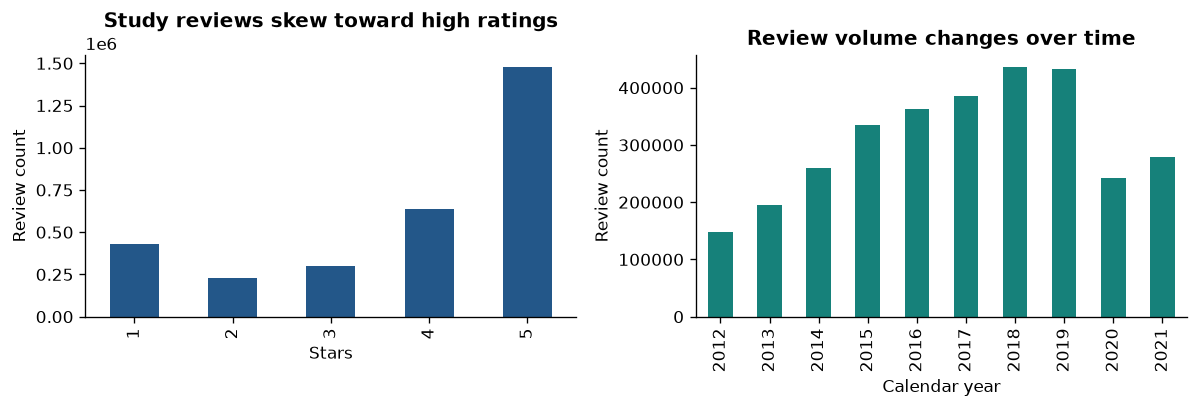

In [3]:
# Stream the existing review-score file: summarize all observations, without loading it all into memory.
score_path = ROOT / 'data/interim/reviews_5metro.csv'
ratings = Counter(); score_missing = Counter(); score_rows = 0; bad_scores = 0
score_years = Counter(); sum_compound = 0.0; sum_stars = 0.0
for chunk in pd.read_csv(score_path, dtype={'zip5':str}, chunksize=200000):
    score_rows += len(chunk)
    ratings.update(chunk['stars'].value_counts().to_dict())
    score_missing.update(chunk.isna().sum().to_dict())
    score_years.update(chunk['date'].str[:4].value_counts().to_dict())
    bad_scores += int((~chunk['compound'].between(-1,1) | ~chunk['stars'].between(1,5)).sum())
    sum_compound += chunk['compound'].sum(); sum_stars += chunk['stars'].sum()
assert score_rows == int(sent['n_reviews'].sum()) and bad_scores == 0
assert abs(sum_compound/score_rows - np.average(sent['mean_compound'],weights=sent['n_reviews'])) < 0.0001
assert abs(sum_stars/score_rows - np.average(sent['mean_stars'],weights=sent['n_reviews'])) < 0.001
print(f'{score_rows:,} scored reviews reconcile with the ZIP-quarter panel; saved score ranges and weighted means pass checks.')
display(pd.Series(score_missing,name='Missing values in full review-score file').to_frame())
fig,ax=plt.subplots(1,2,figsize=(10,3.5))
pd.Series(ratings).sort_index().plot.bar(ax=ax[0],color=COLORS[0]);ax[0].set(title='Study reviews skew toward high ratings',xlabel='Stars',ylabel='Review count')
pd.Series(score_years).sort_index().plot.bar(ax=ax[1],color=COLORS[1]);ax[1].set(title='Review volume changes over time',xlabel='Calendar year',ylabel='Review count')
showfig('01_ratings_and_time')

#### Text sample and raw-source check
We stream every raw review, retaining only records whose business is in the study ZIP list and whose date is in 2012–2021. A seeded reservoir selects up to 1,000 reviews **within each region**, independent of star rating. This creates a balanced regional diagnostic sample; its pooled statistics are not estimates weighted to the full review population.

Text length uses whitespace-separated words. Vocabulary uses lowercase alphabetic tokens of at least two characters; this is a sample vocabulary, not the vocabulary of all reviews. We check missing text across all eligible raw reviews, and duplicate IDs/text only within the diagnostic sample.

Raw reviews scanned: 6,990,280; eligible: 3,073,181; blank eligible texts: 0; malformed JSON: 0
Sampled documents: 5,000; distinct sample tokens: 17,295; repeated sample IDs: 0; repeated exact sample texts: 0


,documents,median_words,mean_words,max_words
metro,,,,
Nashville,1000,72.000,99.963,883
NewOrleans,1000,71.000,99.165,885
Philadelphia,1000,82.000,114.782,938
TampaBay,1000,68.000,94.824,768
Tucson,1000,70.000,101.994,827


,words,characters
count,"5,000.000","5,000.000"
mean,102.100,553.500
std,97.900,526.400
min,5.000,38.000
25%,40.000,220.000
50%,72.000,393.000
75%,131.000,707.000
95%,281.000,"1,515.000"
max,938.000,"4,999.000"


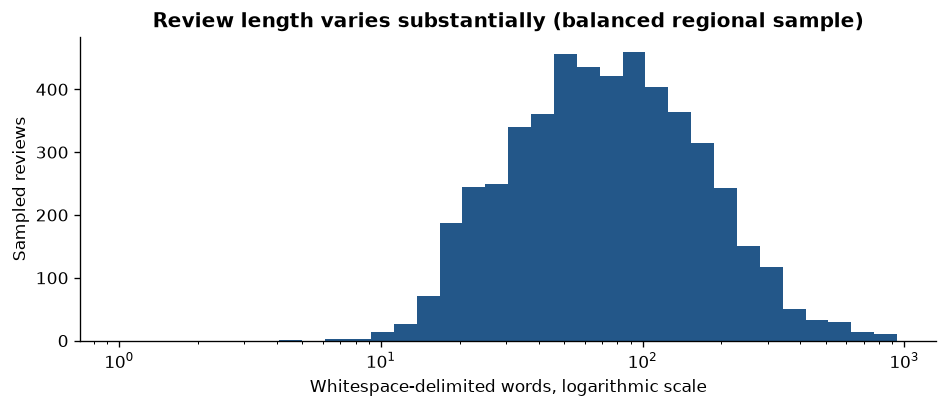

In [4]:
tar_path = ROOT / 'Yelp JSON/yelp_dataset.tar'
text_sig = signature([tar_path,business_path,ROOT/'data/interim/metro_zips.json']) + f'-{SEED}-{SAMPLE_PER_REGION}-v1'
text_cache = CACHE/'review_sample.json.gz'; audit_cache = CACHE/'review_audit.json'
if audit_cache.exists() and text_cache.exists() and json.loads(audit_cache.read_text()).get('signature') == text_sig:
    audit = json.loads(audit_cache.read_text())
    with gzip.open(text_cache,'rt') as f: sample = pd.DataFrame(json.load(f))
else:
    lookup = biz.set_index('business_id')['metro'].to_dict()
    pools = {m:[] for m in metro_zips}; seen = Counter(); rng = random.Random(SEED)
    audit = {'signature':text_sig,'scanned':0,'malformed':0,'eligible':0,'blank_text':0}
    with tarfile.open(tar_path,'r|*') as archive:
        for member in archive:
            if Path(member.name).name != 'yelp_academic_dataset_review.json': continue
            for line in archive.extractfile(member):
                audit['scanned'] += 1
                try: r = json.loads(line)
                except ValueError: audit['malformed'] += 1; continue
                m = lookup.get(r.get('business_id'))
                date = r.get('date') or ''
                if m is None or not '2012' <= date[:4] <= '2021': continue
                audit['eligible'] += 1
                text = r.get('text') or ''; audit['blank_text'] += int(not text.strip())
                seen[m] += 1
                item = {k:r.get(k) for k in ['review_id','business_id','date','stars']}
                item.update(metro=m,text=text)
                if len(pools[m]) < SAMPLE_PER_REGION: pools[m].append(item)
                else:
                    j = rng.randrange(seen[m])
                    if j < SAMPLE_PER_REGION: pools[m][j] = item
            break
    audit['region_counts'] = dict(seen)
    sample = pd.DataFrame([r for pool in pools.values() for r in pool])
    with gzip.open(text_cache,'wt') as f: json.dump(sample.to_dict('records'),f)
    audit_cache.write_text(json.dumps(audit,indent=2))
assert audit['eligible'] == score_rows, 'Raw extraction and saved scores disagree.'
sample['words'] = sample['text'].str.split().str.len()
sample['characters'] = sample['text'].str.len()
vocab = set(token for text in sample['text'] for token in re.findall(r'[a-z]{2,}',text.lower()))
print(f"Raw reviews scanned: {audit['scanned']:,}; eligible: {audit['eligible']:,}; blank eligible texts: {audit['blank_text']:,}; malformed JSON: {audit['malformed']:,}")
print(f'Sampled documents: {len(sample):,}; distinct sample tokens: {len(vocab):,}; repeated sample IDs: {sample.review_id.duplicated().sum()}; repeated exact sample texts: {sample.text.duplicated().sum()}')
display(sample.groupby('metro').agg(documents=('text','size'),median_words=('words','median'),mean_words=('words','mean'),max_words=('words','max')))
display(sample[['words','characters']].describe(percentiles=[.25,.5,.75,.95]).round(1))
fig,ax=plt.subplots(figsize=(8,3.5));ax.hist(sample['words'],bins=np.logspace(0,np.log10(max(2,sample.words.max())),35),color=COLORS[0]);ax.set_xscale('log');ax.set(title='Review length varies substantially (balanced regional sample)',xlabel='Whitespace-delimited words, logarithmic scale',ylabel='Sampled reviews');showfig('02_text_length')

#### Reconstructing federal assistance transactions
The following reads one place-of-performance assistance download per year. We keep transaction identifiers, dates, program information, descriptions, and obligation amounts. Duplicate transaction IDs are checked before aggregation. Negative obligations remain negative; missing/invalid amounts are reported and excluded from totals rather than silently replaced with zero.

In [5]:
raw = ROOT/'data/raw/usaspending'
archives = [raw/f'assistance_{y}.zip' for y in range(2012,2022)]
assert all(p.exists() for p in archives), 'An annual assistance source is missing.'
fund_sig = signature(archives+[ROOT/'data/interim/metro_zips.json'])+'-v1'
fund_cache=CACHE/'assistance.csv.gz'; fund_meta=CACHE/'assistance_audit.json'
fields = ['assistance_transaction_unique_key','assistance_award_unique_key','action_date',
    'federal_action_obligation','primary_place_of_performance_zip_4','cfda_number','cfda_title',
    'transaction_description','awarding_agency_name']
if fund_meta.exists() and fund_cache.exists() and json.loads(fund_meta.read_text()).get('signature')==fund_sig:
    funding=pd.read_csv(fund_cache,dtype=str,keep_default_na=False)
    funding_audit=json.loads(fund_meta.read_text())
else:
    pieces=[]; inventory=[]
    for path in archives:
        scanned=kept=0
        with zipfile.ZipFile(path) as z:
            for member in z.namelist():
                if not member.endswith('.csv'): continue
                with z.open(member) as f:
                    for part in pd.read_csv(f,usecols=fields,dtype=str,keep_default_na=False,chunksize=50000):
                        scanned+=len(part)
                        part['zip5']=part['primary_place_of_performance_zip_4'].str.strip().str.extract(r'^(\d{5})',expand=False)
                        part=part[part['zip5'].isin(zip_metro)].copy()
                        part['source_file']=path.name;kept+=len(part);pieces.append(part)
        inventory.append({'file':path.name,'download_rows':scanned,'study_rows':kept})
    funding=pd.concat(pieces,ignore_index=True)
    funding_audit={'signature':fund_sig,'inventory':inventory}
    funding.to_csv(fund_cache,index=False,compression='gzip');fund_meta.write_text(json.dumps(funding_audit,indent=2))
funding['date']=pd.to_datetime(funding['action_date'],errors='coerce')
funding['obligation']=pd.to_numeric(funding['federal_action_obligation'],errors='coerce')
funding['metro']=funding['zip5'].map(zip_metro)
funding['year']=funding['date'].dt.year
funding['quarter']=funding['date'].dt.to_period('Q').astype(str)
key='assistance_transaction_unique_key'
duplicate_ids=funding.loc[funding[key].ne(''),key].duplicated().sum()
assert duplicate_ids==0, 'Resolve duplicate transaction IDs before summing.'
assert funding['date'].notna().all() and funding['year'].between(2012,2021).all()
assert funding['year'].astype(int).astype(str).eq(funding['source_file'].str.extract(r'(\d{4})',expand=False)).all()
display(pd.DataFrame(funding_audit['inventory']))
print(f'{len(funding):,} transactions; {funding.assistance_award_unique_key.nunique():,} distinct award keys; {funding.zip5.nunique()} ZIPs; {duplicate_ids} repeated nonblank transaction IDs.')
display(pd.DataFrame({'field':['transaction key','award key','program code','program title','transaction description','obligation'],
 'missing_or_blank':[funding[key].eq('').sum(),funding.assistance_award_unique_key.eq('').sum(),funding.cfda_number.eq('').sum(),funding.cfda_title.eq('').sum(),funding.transaction_description.str.strip().eq('').sum(),funding.obligation.isna().sum()]}))
display(funding['obligation'].describe(percentiles=[.25,.5,.75,.95,.99]).to_frame('Nominal transaction obligations ($)'))
print('Negative adjustments:',int(funding.obligation.lt(0).sum()),'| Zero amounts:',int(funding.obligation.eq(0).sum()))

,file,download_rows,study_rows
0,assistance_2012.zip,18467,8286
1,assistance_2013.zip,23706,9849
2,assistance_2014.zip,32586,11030
3,assistance_2015.zip,34575,11452
4,assistance_2016.zip,40445,14159
5,assistance_2017.zip,26057,12026
6,assistance_2018.zip,25840,11202
7,assistance_2019.zip,25177,11038
8,assistance_2020.zip,29828,12499
9,assistance_2021.zip,29550,11853


113,394 transactions; 35,052 distinct award keys; 210 ZIPs; 0 repeated nonblank transaction IDs.


,field,missing_or_blank
0,transaction key,0
1,award key,0
2,program code,0
3,program title,0
4,transaction description,37
5,obligation,0


,Nominal transaction obligations ($)
count,"113,394.000"
mean,"478,221.497"
std,"7,288,168.630"
min,"-191,429,803.000"
25%,516.000
50%,"95,000.000"
75%,"345,487.750"
95%,"1,110,830.450"
99%,"6,534,821.010"
max,"1,658,425,387.000"


Negative adjustments: 13917 | Zero amounts: 13019


### 5. Data quality and suitability
**Coverage is a substantive finding.** A ZIP with a few reviews cannot support a stable quarterly sentiment estimate. We report coverage at thresholds of 10, 30, and 100 reviews; 30 is an exploratory minimum, not a statistical guarantee. Multiple reviews may come from the same person or business, so later uncertainty estimates must account for clustering.

**Geography requires care.** Postal ZIPs and Census ZCTAs are different geographic concepts. Not every ZIP has a ZCTA, and a current boundary is not necessarily valid for a 2012 observation. In this study frame the gap is substantial: **196 of 277 study ZIPs (70.8%) match a ZCTA identifier, leaving 81 ZIPs with no polygon available to draw.** Coverage is uneven by region — New Orleans matches 22 of 40 ZIPs (55%) and Tampa Bay 65 of 98 (66%), against 50 of 59 (85%) in Philadelphia. Because the deliverable is a map, this is a design constraint rather than only a data note: the interface must either render these ZIPs through an alternative geometry or mark them as unmapped, instead of silently omitting them. An exact code match below is a coverage diagnostic, not a completed point-in-polygon or historical boundary validation. [Census explanation](https://www.census.gov/programs-surveys/geography/guidance/geo-areas/zctas.html)

**Funding location is not a benefit footprint.** A recorded place-of-performance ZIP can cover institutional or regional activity; we cannot assume every dollar benefits the businesses in that ZIP. We also cannot interpret a missing funding row as no public investment, because this extract excludes other award types and state/local spending.

**Selection and measurement limit the research question.** Yelp users and listed businesses are self-selected. Review volume, category mix, business entry/exit, and the pandemic may change the composition of reviewers. Snapshot `is_open` is not a historical closure date. VADER is a baseline text score, not a validated measure of neighborhood quality. We retain three-star reviews in the descriptive EDA; a binary sentiment check below explicitly excludes them.

,field,missing_in_study
0,business_id,0
1,postal_code,0
2,latitude,0
3,longitude,0
4,categories,32
5,is_open,0


,listed_ZIPs,ZIPs_with_reviews,ZIPs_with_ZCTA,possible_ZIP_quarters,observed_quarters,quarters_30plus
region,,,,,,
Tucson,47,47,36,1880,1586,1053
Philadelphia,59,59,50,2360,2213,1683
TampaBay,98,98,65,3920,3064,2341
Nashville,33,33,23,1320,1095,741
NewOrleans,40,40,22,1600,1210,730


,minimum_reviews,retained_ZIP_quarters,ZIPs,share_of_reviews_pct
0,10,7399,207,99.828
1,30,6548,185,99.322
2,100,4890,157,95.940


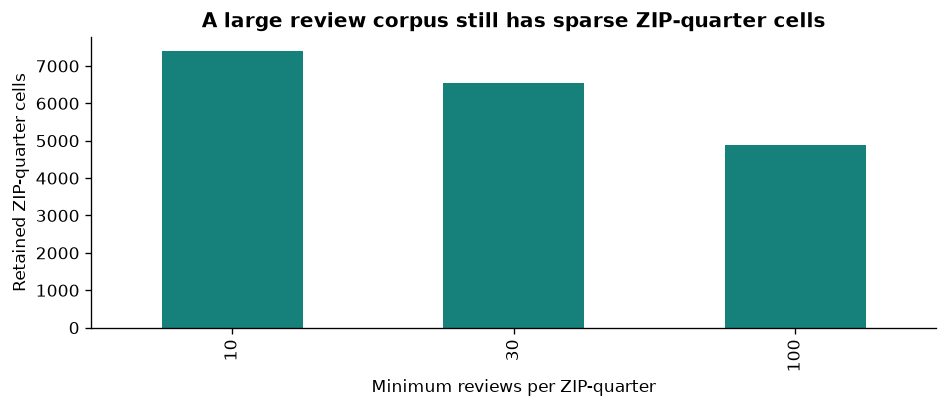

In [6]:
# Missing values in business fields used for scope, mapping, and later controls.
fields_b=['business_id','postal_code','latitude','longitude','categories','is_open']
display(pd.DataFrame({'field':fields_b,'missing_in_study':[biz[c].isna().sum()+biz[c].astype('string').str.strip().eq('').fillna(False).sum() for c in fields_b]}))
geo=json.loads((ROOT/'data/interim/zcta_boundaries.geojson').read_text())
geo_ids={str(f['properties']['GEOID']) for f in geo['features']}
coverage=[]
for m,zs in metro_zips.items():
    s=sent[sent.metro.eq(m)]
    coverage.append({'region':m,'listed_ZIPs':len(zs),'ZIPs_with_reviews':s.zip5.nunique(),
       'ZIPs_with_ZCTA':len(set(zs)&geo_ids),'possible_ZIP_quarters':len(zs)*40,
       'observed_quarters':len(s),'quarters_30plus':int(s.n_reviews.ge(30).sum())})
display(pd.DataFrame(coverage).set_index('region'))
thresholds=pd.DataFrame([{'minimum_reviews':n,'retained_ZIP_quarters':int(sent.n_reviews.ge(n).sum()),
    'ZIPs':sent.loc[sent.n_reviews.ge(n),'zip5'].nunique(),
    'share_of_reviews_pct':100*sent.loc[sent.n_reviews.ge(n),'n_reviews'].sum()/score_rows} for n in [10,30,100]])
display(thresholds)
fig,ax=plt.subplots(figsize=(8,3.5));thresholds.plot.bar(x='minimum_reviews',y='retained_ZIP_quarters',legend=False,ax=ax,color=COLORS[1]);ax.set(title='A large review corpus still has sparse ZIP-quarter cells',xlabel='Minimum reviews per ZIP-quarter',ylabel='Retained ZIP-quarter cells');showfig('03_coverage')

### 6. Preliminary exploration
#### Review sentiment, star ratings, and language
We independently score the balanced regional text sample with VADER. Standard categories are negative at compound ≤ −0.05, neutral between −0.05 and +0.05, and positive at ≥ +0.05. The rating comparison treats 1–2 stars as negative and 4–5 as positive; three stars are excluded only from that comparison. Stars are a useful proxy, not independently annotated sentiment truth. [VADER method and thresholds](https://github.com/cjhutto/vaderSentiment)

For common terms, we count whether a word occurs in each sampled review (document frequency), rather than letting repeated words in long reviews dominate. Stop words are removed only for this descriptive word table, not before VADER scoring.

vader_label,negative,neutral,positive
rating_label,,,
negative,517,26,479
positive,66,10,3400


In the diagnostic sample, **49.4% of 1–2-star reviews are not labeled negative by VADER** (neutral and positive combined). This disagreement requires manual review before interpreting scores as neighborhood signals.

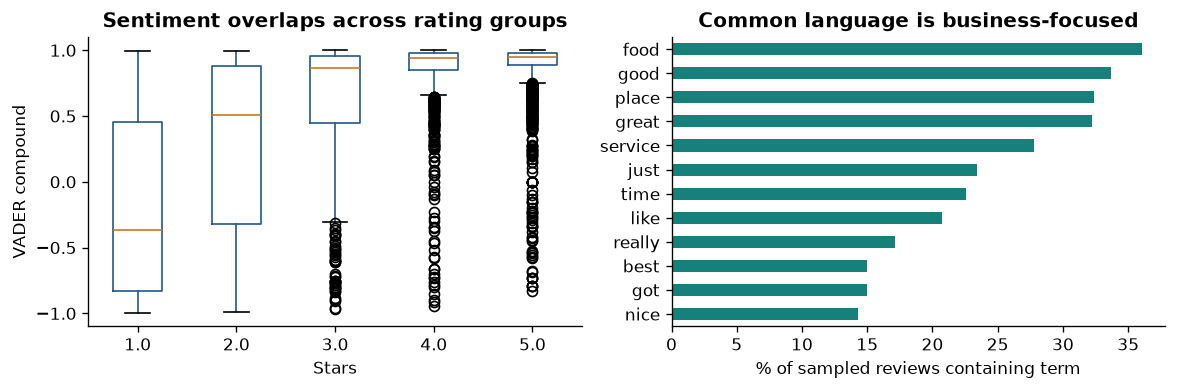

Sample label shares (%):


,percent
vader_label,
positive,86.000
negative,12.900
neutral,1.100


In [7]:
analyzer=SentimentIntensityAnalyzer()
sample['compound']=sample['text'].map(lambda t:analyzer.polarity_scores(t)['compound'])
sample['vader_label']=np.select([sample.compound.le(-.05),sample.compound.ge(.05)],['negative','positive'],default='neutral')
labels=['negative','neutral','positive']
check=sample[sample.stars.ne(3)].copy()
check['rating_label']=np.where(check.stars.le(2),'negative','positive')
comparison=pd.crosstab(check['rating_label'],check['vader_label']).reindex(index=['negative','positive'],columns=labels,fill_value=0)
display(comparison)
negative_miss=1-comparison.loc['negative','negative']/comparison.loc['negative'].sum()
display(Markdown(f'In the diagnostic sample, **{negative_miss:.1%} of 1–2-star reviews are not labeled negative by VADER** (neutral and positive combined). This disagreement requires manual review before interpreting scores as neighborhood signals.'))
fig,ax=plt.subplots(1,2,figsize=(10,3.5))
sample.boxplot(column='compound',by='stars',ax=ax[0],grid=False);ax[0].set(title='Sentiment overlaps across rating groups',xlabel='Stars',ylabel='VADER compound');fig.suptitle('')
vec=CountVectorizer(binary=True,stop_words='english',min_df=5,token_pattern=r'(?u)\b[a-zA-Z]{2,}\b')
x=vec.fit_transform(sample['text']);freq=pd.Series(np.asarray(x.sum(axis=0)).ravel(),index=vec.get_feature_names_out()).sort_values(ascending=False)
(freq.head(12).iloc[::-1]/len(sample)*100).plot.barh(ax=ax[1],color=COLORS[1]);ax[1].set(title='Common language is business-focused',xlabel='% of sampled reviews containing term')
showfig('04_sentiment_and_terms')
print('Sample label shares (%):');display((sample.vader_label.value_counts(normalize=True)*100).round(1).to_frame('percent'))

#### Comparison with a trivial baseline
The table above covers 4,498 sampled reviews, of which 3,476 (**77.3%**) are 4–5 star. A constant "positive" prediction therefore scores 77.3% accuracy. VADER scores (517 + 3,400) / 4,498 = **87.1%**.

The lexicon adds roughly ten points over predicting a single class, and almost all of its error falls on one side: **479 of 1,022 low-star reviews (46.9%) are labeled actively positive**, not merely neutral. Overall accuracy is therefore the wrong headline measure for this project. A sentiment model for our purpose must be judged on negative-class recall, because the neighborhoods we most need to distinguish are the ones where complaints are being written.


#### Time patterns and composition
The following quarterly means weight each ZIP by its number of reviews. They describe the average review, not the average ZIP or resident. We plot review counts alongside sentiment so a change in the volume/composition of reviews is visible. The 2020 marker is temporal context; it does not identify the cause of a change.

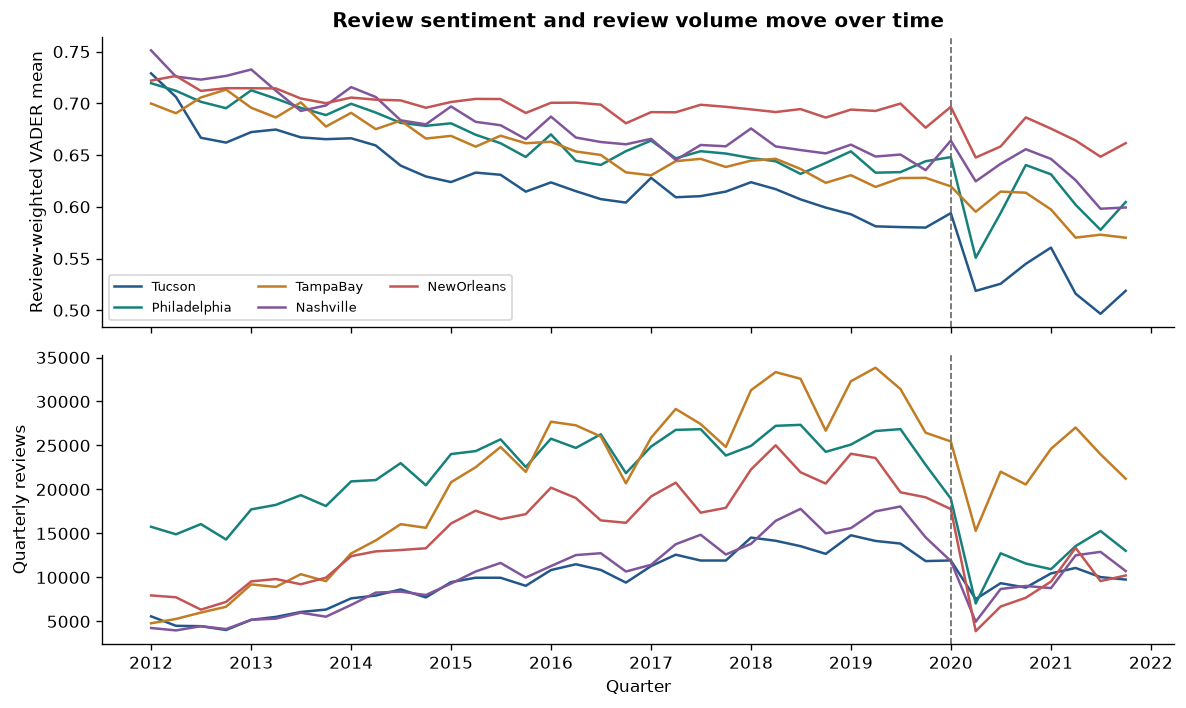

From 2019 to 2020, study review volume changed by **-44.0%**, while the review-weighted mean compound changed by **-0.021**. Their simultaneous movement makes composition and common time shocks important checks for the next stage.

In [8]:
temp=sent.assign(weighted=sent.mean_compound*sent.n_reviews)
trend=temp.groupby(['quarter','metro']).agg(weighted=('weighted','sum'),n=('n_reviews','sum')).reset_index()
trend['mean_compound']=trend['weighted']/trend['n']
fig,ax=plt.subplots(2,1,figsize=(10,6),sharex=True)
for m in metro_zips:
    t=trend[trend.metro.eq(m)].sort_values('quarter');dates=pd.PeriodIndex(t.quarter,freq='Q').to_timestamp()
    ax[0].plot(dates,t.mean_compound,label=m);ax[1].plot(dates,t.n,label=m)
for a in ax:a.axvline(pd.Timestamp('2020-01-01'),ls='--',color='#666666',lw=1)
ax[0].set(title='Review sentiment and review volume move over time',ylabel='Review-weighted VADER mean');ax[0].legend(ncol=3,fontsize=8)
ax[1].set(ylabel='Quarterly reviews',xlabel='Quarter');showfig('05_regional_trends')
annual = temp.groupby('year').agg(n=('n_reviews','sum'),weighted=('weighted','sum'))
annual['mean'] = annual.weighted/annual.n
volume_change = annual.loc[2020,'n']/annual.loc[2019,'n']-1
mean_change = annual.loc[2020,'mean']-annual.loc[2019,'mean']
display(Markdown(f'From 2019 to 2020, study review volume changed by **{volume_change:+.1%}**, while the review-weighted mean compound changed by **{mean_change:+.3f}**. Their simultaneous movement makes composition and common time shocks important checks for the next stage.'))


#### Funding scale, program mix, and descriptions
All included assistance is shown first. It is broader than neighborhood investment. We rank program **codes**, which are more stable grouping keys than title strings, and inspect descriptions to determine what a future relevance classifier must distinguish.

Our exploratory keyword screen matches `housing`, `community development`, `transit`, `transportation`, `infrastructure`, `water`, `sewer`, or `construction` in program titles and transaction descriptions. A match is only a candidate for review; broad programs, boilerplate, and indirect benefits can produce false positives. An unmatched record is not evidence of irrelevance.

,transactions,net_obligations,title
cfda_number,,,
84.425,581,"6,076,678,353.000",EDUCATION STABILIZATION FUND
84.010,75,"2,775,360,435.220",TITLE I GRANTS TO LOCAL EDUCATIONAL AGENCIES
84.027,38,"2,303,834,019.980",SPECIAL EDUCATION_GRANTS TO STATES
10.555,180,"2,175,545,123.770",NATIONAL SCHOOL LUNCH PROGRAM
14.850,7069,"1,859,000,908.930",PUBLIC AND INDIAN HOUSING
20.205,6661,"1,549,431,624.580",HIGHWAY PLANNING AND CONSTRUCTION
93.847,5015,"1,545,964,232.890","DIABETES, DIGESTIVE, AND KIDNEY DISEASES EXTRAMURAL RESEARCH"
93.855,4986,"1,487,608,817.030","ALLERGY, IMMUNOLOGY AND TRANSPLANTATION RESEARCH"


,transactions,net_obligations
candidate_place,,
False,94609,"46,781,650,278.680"
True,18785,"7,445,798,138.210"


Nonblank transaction descriptions: 113,357; distinct exact strings: 31,237. Repeated descriptions are not duplicate transactions.


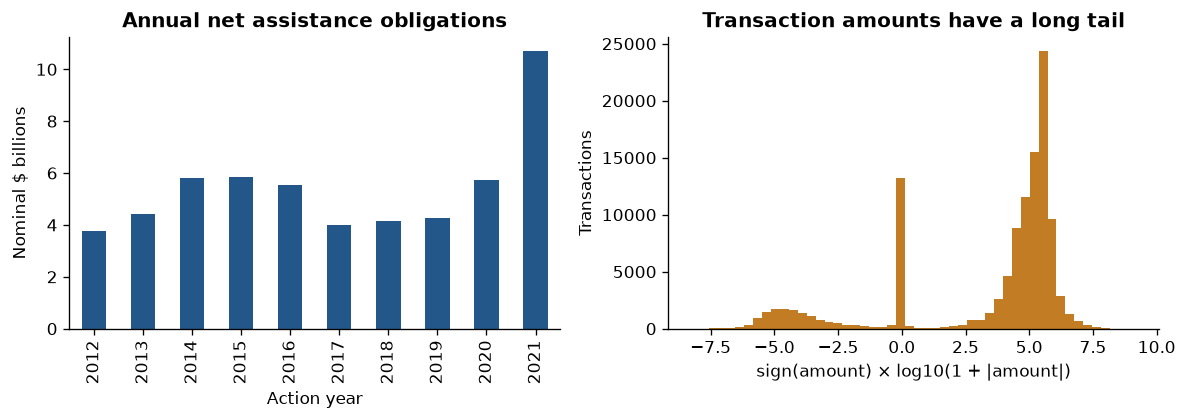

The top five ZIPs account for **54.6% of gross positive obligations** in this extract. Concentrated institutional activity can dominate a regional total; this is a reason to validate location and relevance before treating dollars as local exposure.

The keyword screen identifies **18,785 transactions (16.6%)** for possible local-investment review. The largest program in the unfiltered table is **EDUCATION STABILIZATION FUND**. Thus, total assistance and locally relevant investment are materially different exposure definitions.

In [9]:
valid=funding[funding.obligation.notna()].copy()
programs=valid.groupby('cfda_number').agg(transactions=('obligation','size'),net_obligations=('obligation','sum'),title=('cfda_title','first')).sort_values('net_obligations',ascending=False)
display(programs.head(8))
valid['candidate_place']= (valid.cfda_title+' '+valid.transaction_description).str.contains(r'\bhousing\b|community development|\btransit\b|transportation|infrastructure|\bwater\b|\bsewer\b|construction',case=False,regex=True)
display(valid.groupby('candidate_place').agg(transactions=('obligation','size'),net_obligations=('obligation','sum')))
nonblank=valid.loc[valid.transaction_description.str.strip().ne(''),'transaction_description']
print(f'Nonblank transaction descriptions: {len(nonblank):,}; distinct exact strings: {nonblank.nunique():,}. Repeated descriptions are not duplicate transactions.')
fig,ax=plt.subplots(1,2,figsize=(10,3.6))
(valid.groupby('year').obligation.sum()/1e9).plot.bar(ax=ax[0],color=COLORS[0]);ax[0].set(title='Annual net assistance obligations',xlabel='Action year',ylabel='Nominal $ billions')
transformed=np.sign(valid.obligation)*np.log10(1+valid.obligation.abs())
ax[1].hist(transformed,bins=50,color=COLORS[2]);ax[1].set(title='Transaction amounts have a long tail',xlabel='sign(amount) × log10(1 + |amount|)',ylabel='Transactions')
showfig('06_funding')
positive=valid[valid.obligation.gt(0)].groupby('zip5').obligation.sum().sort_values(ascending=False)
top5_share=positive.head(5).sum()/positive.sum()
display(Markdown(f'The top five ZIPs account for **{top5_share:.1%} of gross positive obligations** in this extract. Concentrated institutional activity can dominate a regional total; this is a reason to validate location and relevance before treating dollars as local exposure.'))
display(Markdown(f'The keyword screen identifies **{valid.candidate_place.sum():,} transactions ({valid.candidate_place.mean():.1%})** for possible local-investment review. The largest program in the unfiltered table is **{programs.iloc[0]["title"]}**. Thus, total assistance and locally relevant investment are materially different exposure definitions.'))


#### Linking funding and review sentiment
We join on recorded ZIP and calendar quarter, after summing transaction obligations. We retain only quarters with at least 30 reviews for this diagnostic. **Unmatched funding rows remain missing**, rather than becoming presumed zero investment. The scatter uses only matched quarters and is explicitly descriptive: no timing, selection, or neighborhood confounding has been resolved.

The x-axis preserves negative net obligations with a signed logarithm. The dollars shown include all selected assistance, not only the keyword-screened candidates. We report correlation as a diagnostic of this particular matched sample, without a causal interpretation or an independence-based significance test.

,metric,value
0,Eligible sentiment ZIP-quarters,6548
1,Matched assistance ZIP-quarters,3505
2,Unmatched sentiment ZIP-quarters,3043
3,ZIPs represented in matched sample,162


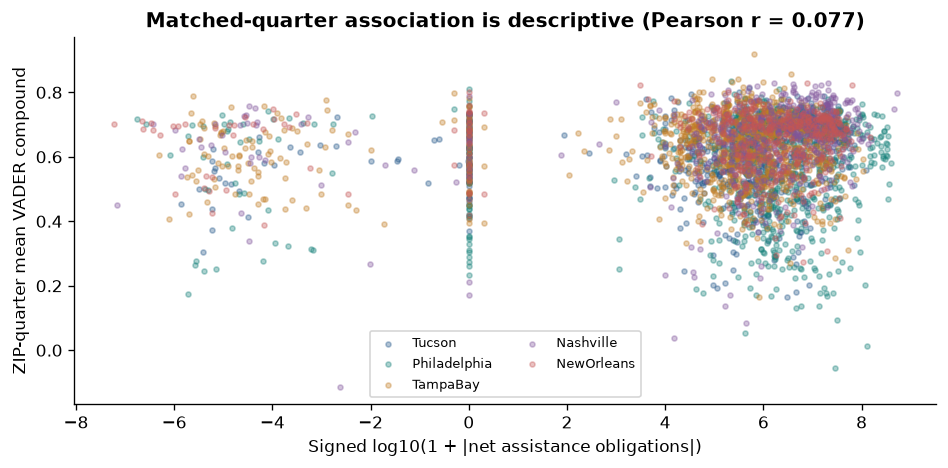

Only **3,505 of 6,548** review-qualified ZIP-quarters have a transaction match in these assistance files (**53.5%**). The matched sample correlation is **0.077**. It does not establish whether funding improves sentiment: the selection of matched cells, program mix, repeated ZIP observations, common time shocks, and delayed effects remain unresolved.

In [10]:
fq=valid.groupby(['zip5','quarter']).agg(net_obligations=('obligation','sum'),transactions=('obligation','size')).reset_index()
joined=sent[sent.n_reviews.ge(30)].merge(fq,on=['zip5','quarter'],how='left',validate='one_to_one',indicator=True)
matched=joined[joined['_merge'].eq('both')].copy()
matched['signed_log']=np.sign(matched.net_obligations)*np.log10(1+matched.net_obligations.abs())
r=matched[['signed_log','mean_compound']].corr().iloc[0,1]
display(pd.DataFrame({'metric':['Eligible sentiment ZIP-quarters','Matched assistance ZIP-quarters','Unmatched sentiment ZIP-quarters','ZIPs represented in matched sample'],
'value':[len(joined),len(matched),len(joined)-len(matched),matched.zip5.nunique()]}))
fig,ax=plt.subplots(figsize=(8,4))
for m in metro_zips:
    p=matched[matched.metro.eq(m)];ax.scatter(p.signed_log,p.mean_compound,s=9,alpha=.35,label=m)
ax.set(title=f'Matched-quarter association is descriptive (Pearson r = {r:.3f})',xlabel='Signed log10(1 + |net assistance obligations|)',ylabel='ZIP-quarter mean VADER compound');ax.legend(fontsize=8,ncol=2);showfig('07_matched_association')
display(Markdown(f'Only **{len(matched):,} of {len(joined):,}** review-qualified ZIP-quarters have a transaction match in these assistance files (**{len(matched)/len(joined):.1%}**). The matched sample correlation is **{r:.3f}**. It does not establish whether funding improves sentiment: the selection of matched cells, program mix, repeated ZIP observations, common time shocks, and delayed effects remain unresolved.'))

#### Robustness: does the association survive our own caveats?

The matched association above (r = 0.077) uses every assistance transaction in the extract. Two checks test whether that number speaks to the question we actually asked. Both were computed from the same `valid` transaction table and ZIP-quarter sentiment panel built earlier in this notebook. They are reported here rather than as executed cells because they were run separately, against `sentiment_zip_quarter.csv` and the annual assistance archives only; the code below reproduces them without the raw Yelp archive. The all-assistance row reproduces the published figures exactly (3,505 of 6,548 matched, r = +0.0773), which is the check that the rest of the table is computed the same way.

**Check 1 — restrict exposure to plausibly local investment.** Section 6 already shows that the keyword screen and the full extract describe different things. Applying the screen to the exposure variable:

| Exposure definition | Matched ZIP-quarters | Share of eligible | Pearson r |
|---|---:|---:|---:|
| All assistance | 3,505 | 53.5% | **+0.077** |
| Keyword-screened only | 1,448 | 22.1% | **+0.011** |

Across the 1,448 cells where both are defined, the two exposure measures correlate at only 0.49 (Spearman 0.59). Restricting to programs with a defensible neighborhood mechanism removes roughly 85% of the association and two-thirds of the matched coverage.

**Check 2 — separate change within a place from differences between places.** Our question is whether a neighborhood's sentiment moves after investment, which is a within-place claim. Decomposing the pooled correlation:

| Variation used | Observations | Pearson r |
|---|---:|---:|
| Pooled (as published) | 3,505 | +0.077 |
| Between ZIPs (one mean per ZIP) | 162 | +0.111 |
| Within ZIP (each ZIP's own mean removed) | 3,505 | **+0.010** |

The pooled figure is almost entirely cross-sectional: ZIPs that receive more federal money differ somewhat in average sentiment from ZIPs that receive less. Once each ZIP is compared with itself over time, the association is +0.010.

**The pandemic is not the explanation.** Excluding 2020–2021 *raises* the all-assistance correlation to +0.123 (n = 2,738) and leaves the screened correlation at +0.014 (n = 1,115). The Education Stabilization Fund is large and confined to 2020–2021, and 2021 net obligations (USD 10.70B) are more than double 2019 (USD 4.25B), but that concentration dampens the association rather than producing it.

**What this means.** We cannot claim from this EDA that public investment is associated with neighborhood review sentiment. The association visible in the pooled scatter is carried by differences between places and by programs we cannot defend as neighborhood investment. This is a finding about measurement and design, not evidence that investment has no effect: a within-place effect could exist and remain undetectable at ZIP-quarter resolution with a review-based proxy whose disagreement with star ratings is documented in section 6. It sets the agenda for the next stage — award relevance classification, a within-place comparison, and a validated sentiment measure are prerequisites rather than refinements.

```python
# Reproduces the two tables above from the annual assistance archives and
# sentiment_zip_quarter.csv. `valid` and `sent` are built as in sections 4 and 6.
SCREEN = (r'\bhousing\b|community development|\btransit\b|transportation'
          r'|infrastructure|\bwater\b|\bsewer\b|construction')
valid['candidate'] = (valid.cfda_title + ' ' + valid.transaction_description) \
                         .str.contains(SCREEN, case=False, regex=True)

def matched(df):
    fq = df.groupby(['zip5','quarter']).obligation.sum().rename('net').reset_index()
    j = sent[sent.n_reviews.ge(30)].merge(fq, on=['zip5','quarter'],
                                          how='inner', validate='one_to_one')
    j['slog'] = np.sign(j.net) * np.log10(1 + j.net.abs())
    return j, j[['slog','mean_compound']].corr().iloc[0,1]

j_all, r_all = matched(valid)                      # 3,505  +0.0773
j_scr, r_scr = matched(valid[valid.candidate])     # 1,448  +0.0113

within = j_all.copy()                              # remove each ZIP's own mean
for c in ['slog','mean_compound']:
    within[c] -= within.groupby('zip5')[c].transform('mean')
r_within = within[['slog','mean_compound']].corr().iloc[0,1]          # +0.0104
r_between = j_all.groupby('zip5')[['slog','mean_compound']].mean() \
                 .corr().iloc[0,1]                                     # +0.1112
```


#### What the EDA changes about the project
The business question is meaningful, but a map alone cannot answer whether an investment worked. Review-count thresholds, sentiment validation, award relevance, and geographic assignment must be visible in the analysis and eventual interface.

The available observations are sufficient for descriptive comparisons and developing text classifiers. Sufficiency for detecting a neighborhood-level effect depends on the number of independent places, exposure variation, timing, and measurement error—not the headline review count. The diagnostic checks above identify where to focus the next stage.

In [11]:
summary = {
 'raw_reviews_scanned':audit['scanned'],'study_reviews':score_rows,'study_businesses':len(biz),
 'study_ZIPs':len(zip_metro),'observed_ZIP_quarters':len(sent),'review_qualified_ZIP_quarters':len(joined),
 'sample_documents':len(sample),'sample_vocabulary':len(vocab),'assistance_transactions':len(valid),
 'assistance_award_keys':valid.assistance_award_unique_key.nunique(),
 'net_assistance_obligations':float(valid.obligation.sum()),'funding_match_share':len(matched)/len(joined),
 'matched_descriptive_r':float(r),'sample_low_rating_not_negative_share':float(negative_miss),
 'top5_ZIP_positive_obligation_share':float(top5_share)}
(CACHE/'eda_results.json').write_text(json.dumps(summary,indent=2))
display(Markdown(f"""**Findings to carry forward**
- **Coverage:** {score_rows:,} reviews become {len(sent):,} observed ZIP-quarter cells; {len(joined):,} meet the 30-review minimum. Geographic granularity is limited by coverage.
- **Measurement:** {negative_miss:.1%} of sampled low-star reviews are neutral or positive under VADER. We need a manually checked sentiment benchmark.
- **Exposure:** {len(valid):,} assistance transactions include negative adjustments and concentrated funding; the top five ZIPs receive {top5_share:.1%} of gross positive obligations. Program and location validation are essential.
- **Linkage:** {len(matched)/len(joined):.1%} of review-qualified ZIP-quarters match recorded assistance activity. This EDA supports further feasibility work, not a conclusion that public investment causes changes in neighborhood sentiment."""))

**Findings to carry forward**
- **Coverage:** 3,073,181 reviews become 9,168 observed ZIP-quarter cells; 6,548 meet the 30-review minimum. Geographic granularity is limited by coverage.
- **Measurement:** 49.4% of sampled low-star reviews are neutral or positive under VADER. We need a manually checked sentiment benchmark.
- **Exposure:** 113,394 assistance transactions include negative adjustments and concentrated funding; the top five ZIPs receive 54.6% of gross positive obligations. Program and location validation are essential.
- **Linkage:** 53.5% of review-qualified ZIP-quarters match recorded assistance activity. This EDA supports further feasibility work, not a conclusion that public investment causes changes in neighborhood sentiment.

### 7. Proposed AI solution and next steps
| Next-stage component | Method | What it addresses / how we will evaluate it |
|---|---|---|
| Validate review sentiment | Manually annotate a sample stratified by region, year, star rating, and **review length**; compare VADER with TF-IDF + linear SVM, then a pretrained sentiment model if needed | Measure macro F1, per-class recall, and errors by region **and by length bucket** against human text labels. The VADER compound score is normalized across the whole document, so a long critical review may score less negative than a short one; validation must test this directly rather than assume length is neutral. Beat the majority-class baseline on negative recall, not on overall accuracy. Split by business and time to reduce leakage; use star ratings only as weak training labels. |
| Identify locally relevant assistance | Manually label award descriptions as plausibly local physical/community investment, institutional/transfer activity, or uncertain; build a TF-IDF baseline and consider embeddings | Evaluate precision/recall on held-out awards, grouping transactions from the same award together. Review high-dollar cases and preserve an uncertain category. |
| Improve geographic exposure | Check business coordinates against ZCTAs; review boundary vintage and the recorded funding location/benefit footprint | Report join failures and sensitivity to alternate geographic aggregation. Do not assign an entire regional award to a neighborhood without evidence. |
| Examine associations over time | Pre-specify a small set of lags; compare within-ZIP changes with quarter effects and clustered uncertainty | Distinguish persistent place differences from time changes. Audit coverage before interpreting absent transactions as zeros. Avoid selecting the best-looking lag after inspecting many results. |
| Deliver the map | Show review coverage, validated sentiment, funding type, and time filters together | Flag sparse cells and uncertain exposure. Present descriptive patterns and uncertainty instead of claims of investment effectiveness. |

A null or weak relationship remains useful: it may indicate limited sensitivity of this proxy or insufficient geographic resolution, rather than proving that an investment has no effect.

### 8. Generative AI use
OpenAI Codex assisted with organizing this EDA, writing and debugging notebook code, identifying source-provenance issues, producing figures, and drafting interpretations. Anthropic's Claude was used to review the completed notebook against the assignment requirements, to align the section numbering with those requirements, to add the baseline comparison and the robustness subsection in section 6 and the ZCTA coverage figures in section 5, and to verify the HTML export. The robustness figures were computed by Claude from the annual assistance archives and the ZIP-quarter sentiment panel using the code shown beside them, and reproduce the notebook's published matched-sample results exactly before extending them. No previously computed output in this notebook was altered. Numerical findings are computed from the local project data and saved execution outputs. The notebook also reuses the project's existing VADER review scores, checked against a fresh raw-record count and aggregate totals. The creation history of those earlier scripts is not inferred here.

The team is responsible for the analysis, code, and conclusions presented here.

### References
- Yelp Open Dataset: https://www.yelp.com/dataset — local archived business/review data, not current live Yelp reviews.
- USASpending data and API: https://www.usaspending.gov/ and https://api.usaspending.gov/docs/ — the exact annual source filenames and row counts are reported above.
- Census ZCTAs: https://www.census.gov/programs-surveys/geography/guidance/geo-areas/zctas.html — ZIP/ZCTA distinctions.
- Census boundary service used by the project: https://tigerweb.geo.census.gov/arcgis/rest/services/TIGERweb/tigerWMS_ACS2023/MapServer/2
- Hutto & Gilbert, VADER implementation and method: https://github.com/cjhutto/vaderSentiment

### Export
After saving the executed notebook, run:
```bash
python -m nbconvert --to html ProjectEDA_Team4.ipynb
```
The two assignment files are `ProjectEDA_Team4.ipynb` and `ProjectEDA_Team4.html`. Cached source extracts and diagnostic PNGs are local working files.